# Chromatin Peak to Trough Analysis and Metrics

Summarize the chromatin peak-to-trough ratios for each gene. There will be a few methods we can try. 

1. First, let's get an idea of what the peak-to-trough ratio values are for all the chromatin cells for all genes.
2. Then, try a few threshold values to get a sense of how we can partition the genes into cell cycling and non-cell cycling gene groups


In [51]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

In [99]:
analysis = PeakToTroughAnalysis()

Created a dictionary of PTR arrays of size: 5402
So, there were 372 genes that did not deconvolve
Created a numpy array of all deconvolved gene PTRs of shape: (5774, 3, 9)
5344 genes have non-nan deconvolution chromatin PTRs


Truncating large PTR outlier values (1 gene). So N=5755


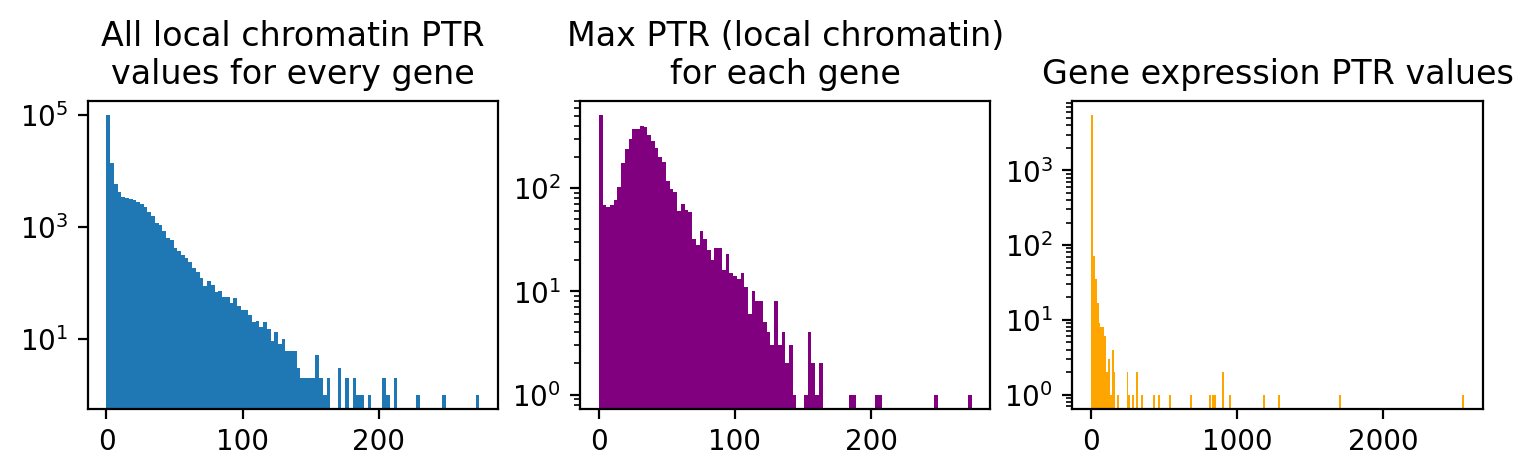

In [101]:
analysis.plot_histograms()

Text(0.5, 1.0, 'Gene expression vs Max chromatin\nPeak-to-trough ratios')

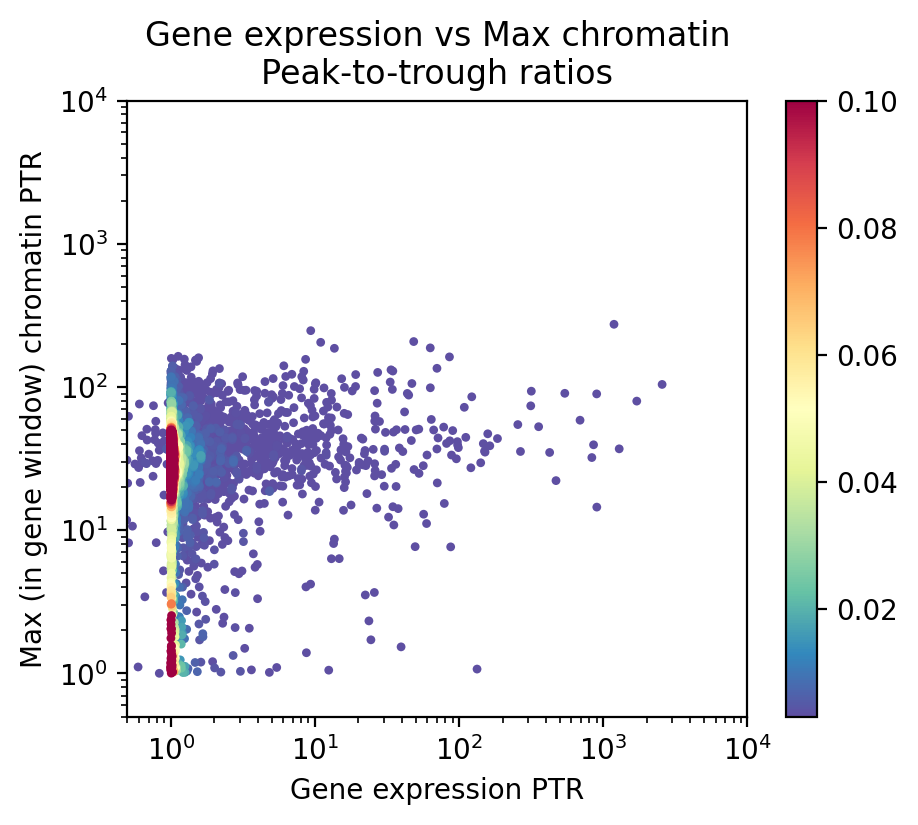

In [144]:
from cc_src.DensityScatterPlotter import DensityScatterPlotter

plt.figure(figsize=(5, 4))
plt_data = analysis.combined_ptr_dfs.copy()
plt_data = plt_data.dropna()

density_plotter = DensityScatterPlotter()
density_plotter.bw = [0.01, 1]
density_plotter.cmap = 'Spectral_r'

density_plotter.set_data(plt_data.ge_ptr, plt_data.max_chrom_ptr)
ax = density_plotter.plot_ax(plt.gca(), plot_colorbar=True, vmax=0.1)

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Gene expression PTR")
plt.ylabel("Max (in gene window) chromatin PTR")
plt.xlim(0.5, 10000)
plt.ylim(0.5, 10000)
plt.title("Gene expression vs Max chromatin\nPeak-to-trough ratios")
